Redes Neuronales

Intento 1 Label

In [ ]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [ ]:
# Cargar el dataset
try:
    df = pd.read_csv("label_encoding.csv", sep=';')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("El archivo no se encuentra. Verificar la ruta.")


Dataset cargado exitosamente.


In [ ]:
# Separar features y target
X = df.drop('GRD', axis=1)
y = df['GRD']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Preparar etiquetas para la red neuronal
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convertir a one-hot encoding
y_train_categorical = to_categorical(y_train_encoded)
y_test_categorical = to_categorical(y_test_encoded)

# Número de clases
n_classes = y_train_categorical.shape[1]
print(f"Número de clases: {n_classes}")

Número de clases: 158


In [ ]:
# Crear el modelo de red neuronal
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(n_classes, activation='softmax')
])

# Compilar el modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Entrenamiendo del modelo
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train_categorical,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1292 - loss: 4.3980 - val_accuracy: 0.3182 - val_loss: 3.0905
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3189 - loss: 2.9863 - val_accuracy: 0.4042 - val_loss: 2.6295
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3861 - loss: 2.5808 - val_accuracy: 0.4257 - val_loss: 2.4465
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3891 - loss: 2.4192 - val_accuracy: 0.4402 - val_loss: 2.3285
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4175 - loss: 2.2725 - val_accuracy: 0.4427 - val_loss: 2.2534
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4452 - loss: 2.1490 - val_accuracy: 0.4567 - val_loss: 2.1813
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4527 - loss: 2.0645 - val_accuracy: 0.4657 - val_loss: 2.1238
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4544 - loss: 2.0439 - val_accuracy: 0.

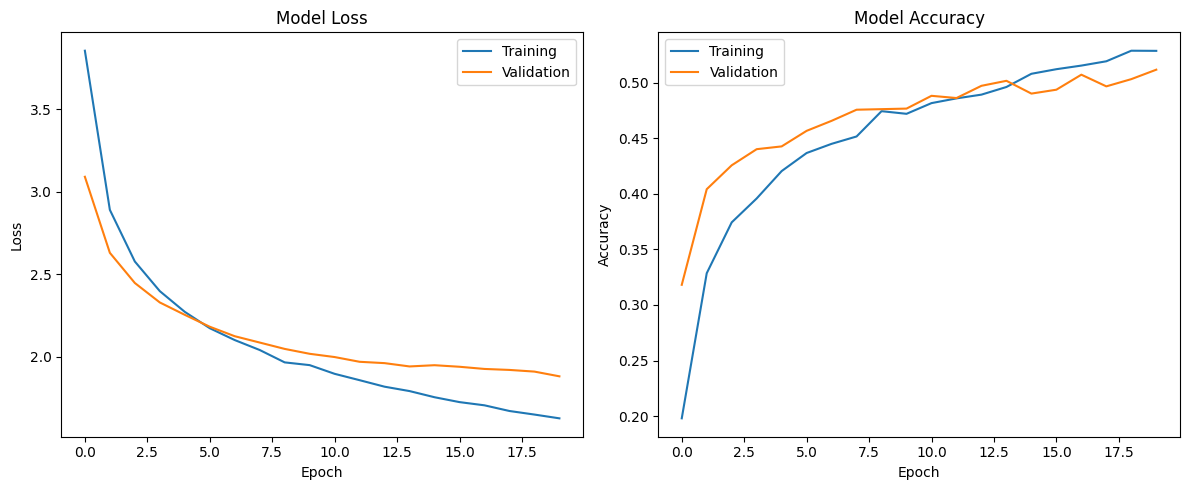

In [ ]:
# Visualizacion del progreso del entrenamiento
plt.figure(figsize=(12, 5))

# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.5119
Precision: 0.4611
Recall: 0.5119


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


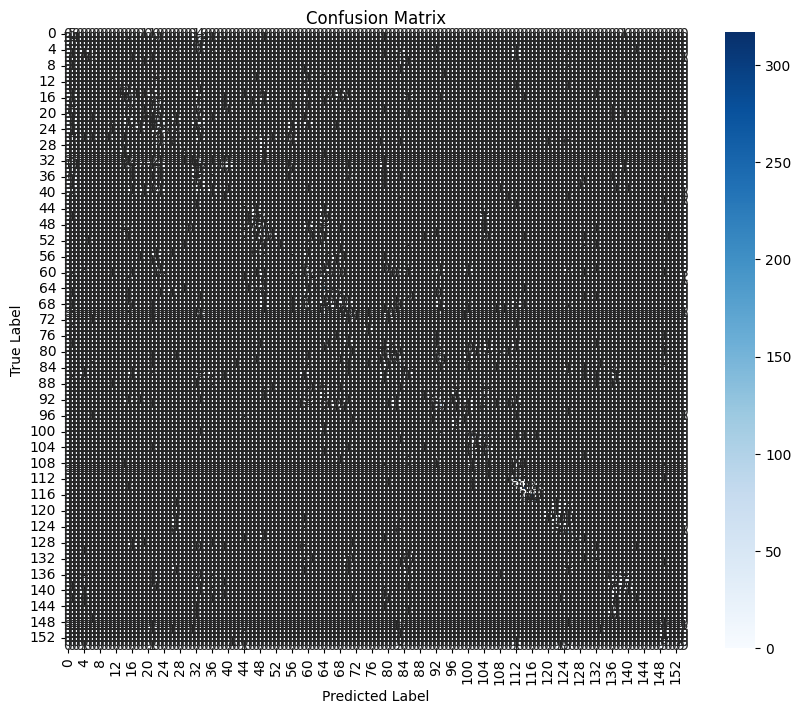

In [ ]:
# Evaluar el modelo
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_test_classes = y_test_encoded

# Calcular métricas
accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision = precision_score(y_test_classes, y_pred_classes, average='weighted')
recall = recall_score(y_test_classes, y_pred_classes, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Mostrar matriz de confusión
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Calcular AUC general (promedio) para multiclase
y_test_bin = label_binarize(y_test_classes, classes=np.arange(n_classes))

# Calcular ROC AUC para cada clase y promediar
roc_auc_macro = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr', average='macro')
roc_auc_weighted = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr', average='weighted')
roc_auc_micro = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr', average='micro')

print(f"ROC AUC (macro-average): {roc_auc_macro:.4f}")
print(f"ROC AUC (weighted-average): {roc_auc_weighted:.4f}")
print(f"ROC AUC (micro-average): {roc_auc_micro:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist

ROC AUC (macro-average): nan
ROC AUC (weighted-average): 0.9694
ROC AUC (micro-average): 0.9796


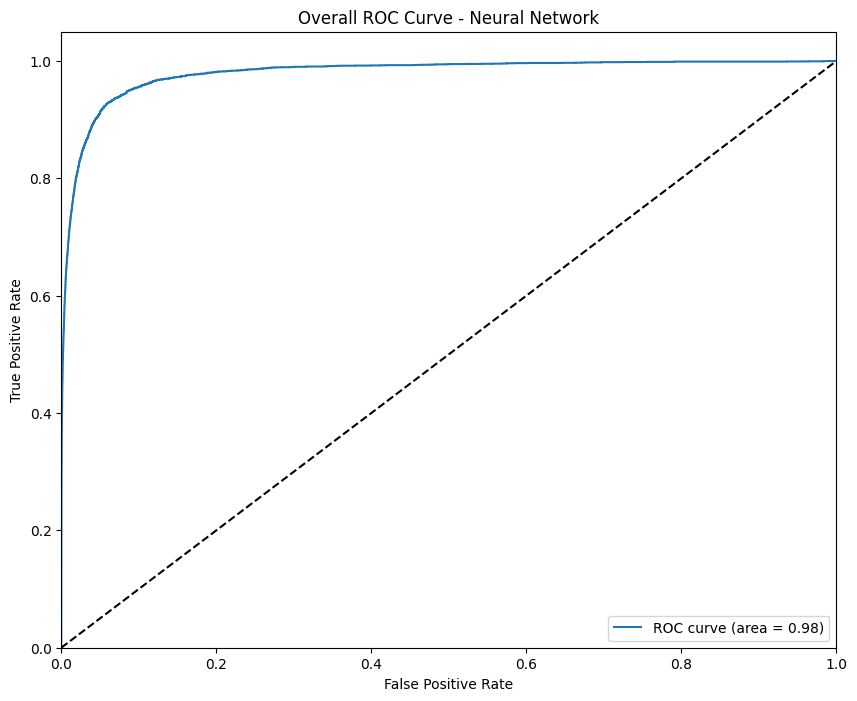

In [ ]:
# Visualizar ROC general (micro-average)
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve - Neural Network')
plt.legend(loc="lower right")
plt.show()

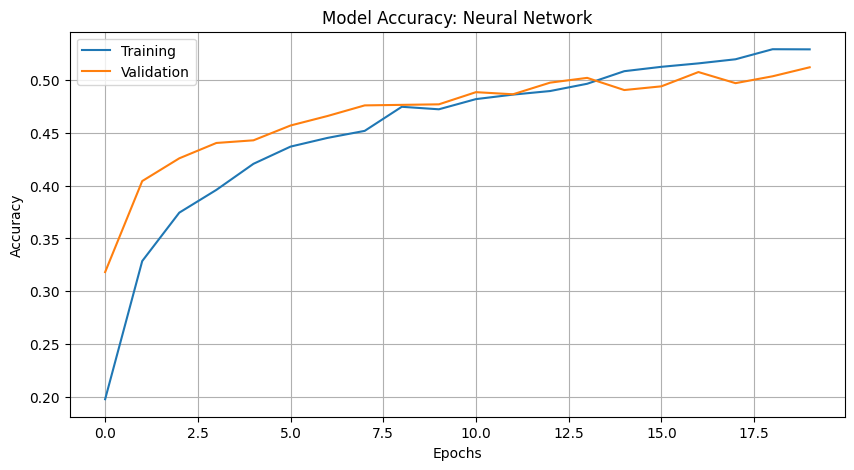

In [ ]:
# Graficar
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy: Neural Network')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
import numpy as np

# Convertir a numpy arrays si son DataFrames de pandas
X_train_np = X_train_scaled.values if hasattr(X_train_scaled, 'values') else X_train_scaled
y_train_np = y_train.values if hasattr(y_train, 'values') else y_train

# Inicializar variables
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

# Bucle manual de validación cruzada
for train_idx, val_idx in kfold.split(X_train_np, y_train_np):
    # Crear y compilar modelo
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_np.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

    # Entrenar y evaluar
    model.fit(X_train_np[train_idx], y_train_np[train_idx],
             epochs=10, batch_size=32, verbose=0)
    score = model.evaluate(X_train_np[val_idx], y_train_np[val_idx], verbose=0)
    scores.append(score[1])  # Agregar precisión

# Convertir a array numpy
scores = np.array(scores)

print("Resultados de validación cruzada 5-fold manual:")
print(f"Precisiones individuales: {scores}")
print(f"Precisión media: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Resultados de validación cruzada 5-fold manual:
Precisiones individuales: [0.45372686 0.45422712 0.45622811 0.46223113 0.47197196]
Precisión media: 0.4597
Desviación estándar: 0.0069


Intento 11 Onehot

Dataset onehot_encoded_data.csv cargado exitosamente.
Dimensiones del dataset: (14279, 15583)
Primeras 5 filas:
   Proced 01 Principal (cod+des)  Proced 02 Secundario (cod+des)  \
0                          86.28                           34.91   
1                          31.10                           86.28   
2                          86.22                           54.59   
3                          54.19                           39.98   
4                          54.11                           45.90   

   Proced 03 Secundario (cod+des)  Proced 04 Secundario (cod+des)  \
0                           88.38                           87.41   
1                           96.72                           93.90   
2                           96.72                           31.10   
3                           86.28                           54.62   
4                           46.73                           46.20   

   Proced 05 Secundario (cod+des)  Proced 06 Secundario (cod+des

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │     3,989,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 158)            │        10,270 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,042,462 (15.42 MB)

 Trainable params: 4,041,566 (15.42 MB)

 Non-trainable params: 896 (3.50 KB)


Entrenando modelo...
Epoch 1/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.1404 - loss: 4.5382 - val_accuracy: 0.4801 - val_loss: 2.6623
Epoch 2/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.4667 - loss: 2.5542 - val_accuracy: 0.5689 - val_loss: 2.1620
Epoch 3/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.6246 - loss: 1.7605 - val_accuracy: 0.5987 - val_loss: 1.9261
Epoch 4/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.7051 - loss: 1.3486 - val_accuracy: 0.6223 - val_loss: 1.7643
Epoch 5/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.7748 - loss: 1.0109 - val_accuracy: 0.6455 - val_loss: 1.6461
Epoch 6/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.8201 - loss: 0.7818 - val_accuracy: 0.6381 - val_loss: 1.7258
Epoch 7/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.8522 - loss: 0.6273 - val_accuracy: 0.6578 - val_loss: 1.6630
Epoch 8/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.

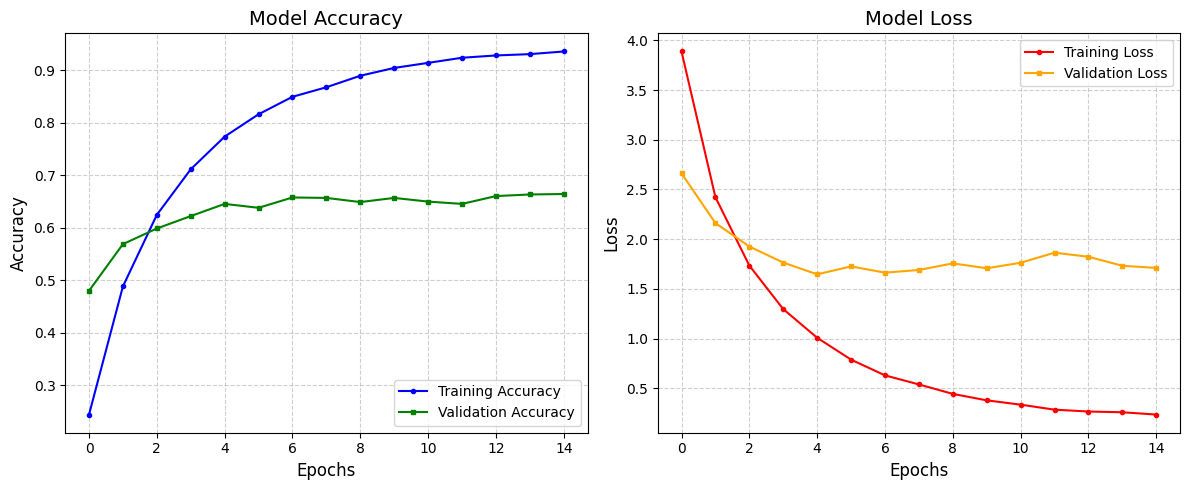


Evaluando modelo en conjunto de prueba...
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

Resultados en el conjunto de prueba:
Accuracy: 0.6835
Precision: 0.6495
Recall: 0.6835


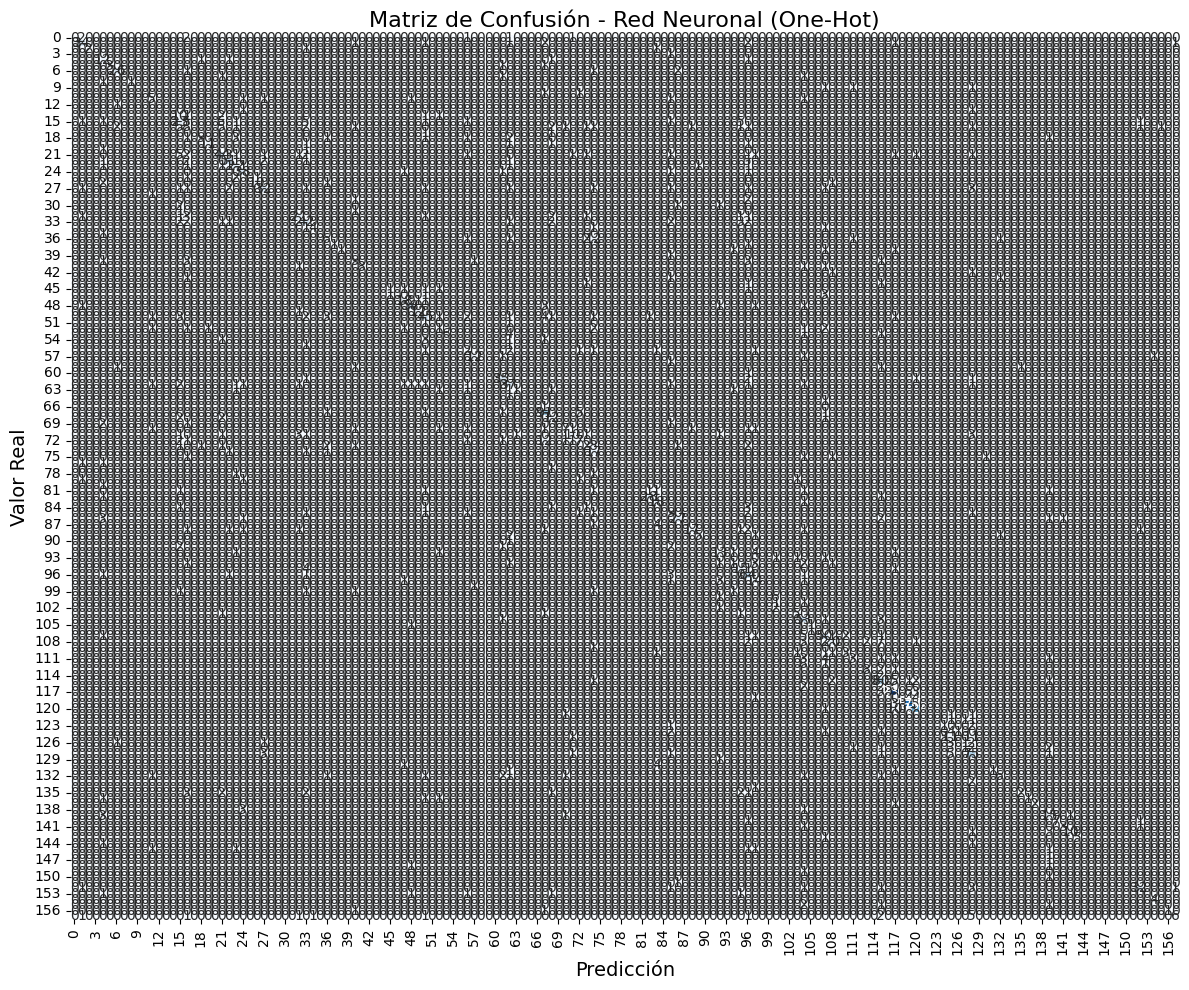

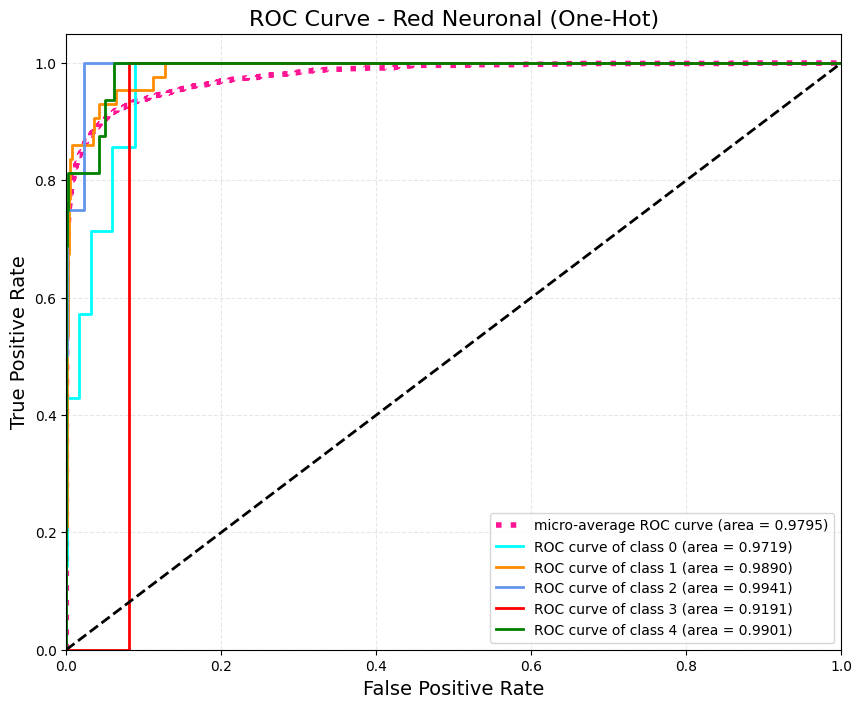


AUC micro-average: 0.9795

Realizando validación cruzada 5-fold...


Resultados de validación cruzada 5-fold:
Accuracy por fold: [0.6407002210617065, 0.6757111549377441, 0.6542669534683228, 0.6449211835861206, 0.6230297684669495]
Accuracy media: 0.6477
Desviación estándar: 0.0173

Accuracy final de entrenamiento: 0.9357
Accuracy final de validación: 0.6643
Brecha entre entrenamiento y validación: 0.2713

Modelo guardado como 'neural_network_onehot_model.h5'

Realizando análisis de errores...

Errores más comunes (Verdadero -> Predicho):
Clase verdadera 120 predicha como 119: 13 veces
Clase verdadera 72 predicha como 67: 12 veces
Clase verdadera 36 predicha como 74: 12 veces
Clase verdadera 125 predicha como 128: 11 veces
Clase verdadera 120 predicha como 117: 10 veces
Clase verdadera 14 predicha como 15: 10 veces
Clase verdadera 73 predicha como 74: 8 veces
Clase verdadera 112 predicha como 104: 8 veces
Clase verdadera 108 predicha como 115: 7 veces
Clase verdadera 117 predicha como 119: 6 veces


In [4]:
# Modelo de Red Neuronal para Predicción de GRD usando datos One-Hot Encoded

# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

try:
    # Intentar cargar el archivo onehot_encoded_data.csv
    df = pd.read_csv("onehot_encoded_data.csv", sep=',')
    print("Dataset onehot_encoded_data.csv cargado exitosamente.")
except FileNotFoundError:
                print("Ningún archivo de datos encontrado. Verificar las rutas.")
                exit()

# Mostrar información básica del dataset
print(f"Dimensiones del dataset: {df.shape}")
print("Primeras 5 filas:")
print(df.head())

# Verificar si la columna 'GRD' existe en el dataset
if 'GRD' not in df.columns:
    print("Error: La columna 'GRD' no existe en el dataset.")
    # Buscar posibles columnas de target
    possible_targets = [col for col in df.columns if 'GRD' in col or 'target' in col.lower() or 'class' in col.lower()]
    if possible_targets:
        print(f"Posibles columnas target encontradas: {possible_targets}")
        target_col = possible_targets[0]
        print(f"Usando '{target_col}' como columna target.")
    else:
        print("No se encontraron posibles columnas target. Asumiendo que la última columna es el target.")
        target_col = df.columns[-1]
        print(f"Usando '{target_col}' como columna target.")
else:
    target_col = 'GRD'

# Separar features y target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Mostrar información sobre las clases
class_counts = y.value_counts()
print("\nDistribución de clases (GRD):")
print(class_counts)
n_classes = len(class_counts)
print(f"Número de clases: {n_classes}")

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar características (importante incluso con one-hot encoding)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# One-hot encode the target variable
lb = LabelBinarizer()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

# Verificar las dimensiones después del preprocesamiento
print(f"\nDimensiones después del preprocesamiento:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"y_train_encoded: {y_train_encoded.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_test_encoded: {y_test_encoded.shape}")

# Definir y compilar el modelo de red neuronal
print("\nCreando modelo de red neuronal...")
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

# Compilar el modelo
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen del modelo
model.summary()

# Configurar early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Entrenar el modelo
print("\nEntrenando modelo...")
history = model.fit(
    X_train_scaled, y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Graficar curvas de aprendizaje (accuracy)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='blue', marker='o', markersize=3, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='green', marker='s', markersize=3, label='Validation Accuracy')
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Graficar curvas de aprendizaje (loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', marker='o', markersize=3, label='Training Loss')
plt.plot(history.history['val_loss'], color='orange', marker='s', markersize=3, label='Validation Loss')
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Evaluar el modelo
print("\nEvaluando modelo en conjunto de prueba...")
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)

# Calcular métricas
accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision = precision_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
recall = recall_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)

print("\nResultados en el conjunto de prueba:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Mostrar matriz de confusión
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Red Neuronal (One-Hot)', fontsize=16)
plt.xlabel('Predicción', fontsize=14)
plt.ylabel('Valor Real', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Calcular y visualizar ROC-AUC para multiclase
# Calcular ROC curve y ROC area para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_encoded[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular micro-average ROC curve y ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_encoded.ravel(), y_pred_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Graficar ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average ROC curve (area = {roc_auc["micro"]:.4f})',
         color='deeppink', linestyle=':', linewidth=4)

# Graficar ROC curve para algunas clases
colors = ['aqua', 'darkorange', 'cornflowerblue', 'red', 'green']
for i, color in zip(range(min(5, n_classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve - Red Neuronal (One-Hot)', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Imprimir AUC promedio
print(f"\nAUC micro-average: {roc_auc['micro']:.4f}")

# Validación cruzada
print("\nRealizando validación cruzada 5-fold...")
# Para validación cruzada, necesitamos una función que entrene y evalúe el modelo
def build_and_evaluate_model(X_train, y_train):
    # Crear y compilar modelo
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Entrenar modelo con early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )

    return model

# Realizar validación cruzada manualmente
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in cv.split(X_train_scaled, y_train):
    # Obtener datos de entrenamiento y validación para esta iteración
    X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_cv_train = y_train_encoded[train_idx]
    y_cv_val = y_train_encoded[val_idx]

    # Entrenar modelo
    cv_model = build_and_evaluate_model(X_cv_train, y_cv_train)

    # Evaluar modelo
    _, accuracy = cv_model.evaluate(X_cv_val, y_cv_val, verbose=0)
    cv_scores.append(accuracy)

# Mostrar resultados de validación cruzada
print(f"Resultados de validación cruzada 5-fold:")
print(f"Accuracy por fold: {[score for score in cv_scores]}")
print(f"Accuracy media: {np.mean(cv_scores):.4f}")
print(f"Desviación estándar: {np.std(cv_scores):.4f}")

# Imprimir los valores finales de accuracy y loss
print(f"\nAccuracy final de entrenamiento: {history.history['accuracy'][-1]:.4f}")
print(f"Accuracy final de validación: {history.history['val_accuracy'][-1]:.4f}")
print(f"Brecha entre entrenamiento y validación: {history.history['accuracy'][-1] - history.history['val_accuracy'][-1]:.4f}")

# Guardar el modelo
model.save("neural_network_onehot_model.h5")
print("\nModelo guardado como 'neural_network_onehot_model.h5'")

# Análisis de errores
print("\nRealizando análisis de errores...")
error_indices = np.where(y_pred_classes != y_test_classes)[0]
error_counts = {}

for idx in error_indices:
    true_class = y_test_classes[idx]
    pred_class = y_pred_classes[idx]
    error_pair = (true_class, pred_class)

    if error_pair in error_counts:
        error_counts[error_pair] += 1
    else:
        error_counts[error_pair] = 1

# Mostrar los errores más comunes
print("\nErrores más comunes (Verdadero -> Predicho):")
sorted_errors = sorted(error_counts.items(), key=lambda x: x[1], reverse=True)
for (true_class, pred_class), count in sorted_errors[:10]:
    print(f"Clase verdadera {true_class} predicha como {pred_class}: {count} veces")
